# Load Functions and Packages

In [357]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.fft import fft, fftfreq
import itertools
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.metrics import auc
from tkinter.filedialog import askdirectory
import tkinter as tk
from ipywidgets import interact, widgets, fixed, interactive, HBox, Layout
import pandas as pd
import numpy as np

# Custom Functions
from FunctionsProcess import *

# Select directory with the data

In [434]:

root = tk.Tk()
# root.withdraw()
root.attributes('-topmost',True)
root.iconify()

test = askdirectory(parent=root, initialdir='C:/IBECPostDocDrive/2023_05_23_PythonMRIProcessing')

root.destroy()


# Process Data

In [435]:
# This block start the processing of the raw spectral data from the MRI
# if the folder selected in the previous block contains the right data. 
# if this block launches an error is probably because the folder does not contain spectral data to process.

indx = [i for i in range(len(test)) if test[i].find('/')==0]
foldPath = test[0:indx[-1]]
foldNum = test[indx[-1]+1:]

rot, RECO_ft_mode, bw, bwc, ACQ_repetition_time, ACQ_Size, NR, bwHz = getMetaDat(foldPath, foldNum)

# Last Argument is Line broadening Factor
ppms, futmag, fut, co3 = ProcDat(foldPath, foldNum, NR, ACQ_Size, rot, bwc, bw, 8)

In [565]:
foldPath

'C:/Users/Vicent/OneDrive - IBEC/MRI ANALYSIS/MRI_analysis_3/1897_3_liver_slab_1_13C_pyruvate_1_1'

# Plot FID

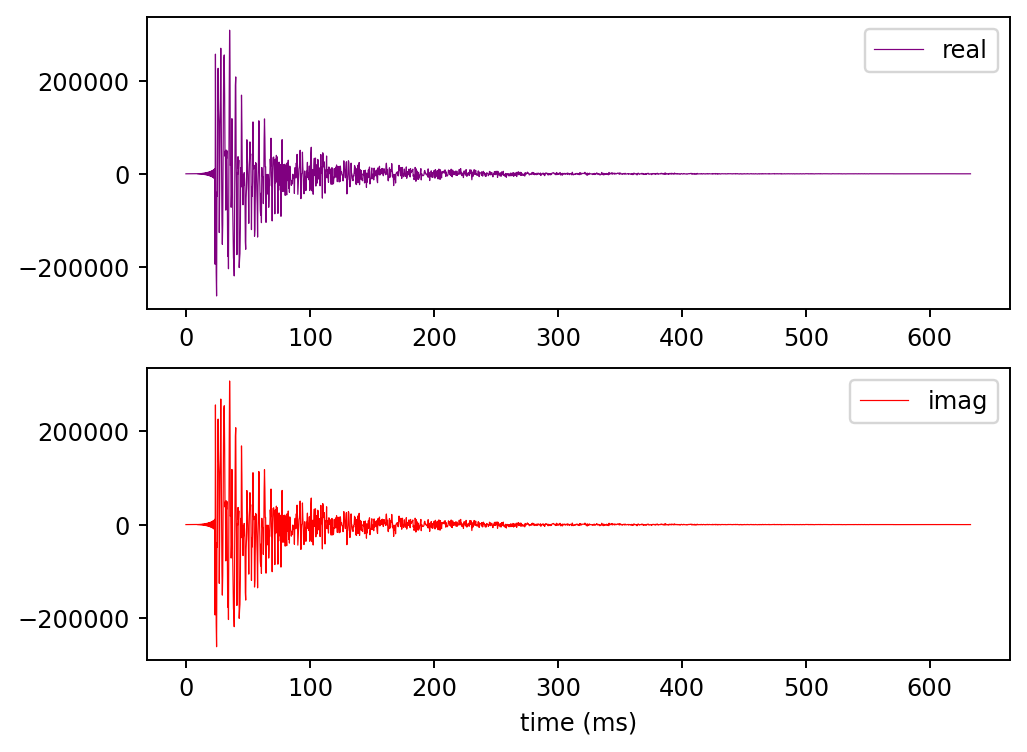

In [437]:
plotFID(8, foldPath, foldNum, co3)

### Plot magnitude spectra for each time point (first argument, starting from 0)

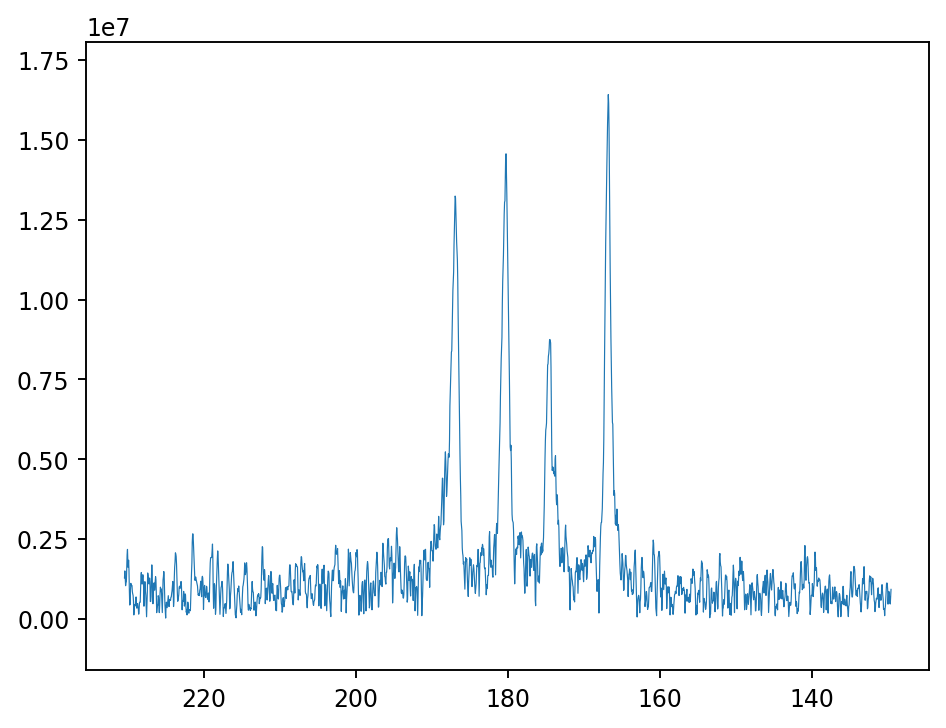

In [438]:
plotSingle(6, ppms, futmag, foldPath, foldNum)

### Check peaks width in PPM and Hz

In [ ]:
mm=interactive(
        integRegs4,
        Noise = widgets.FloatRangeSlider(min=-np.max(ppms),max=-np.min(ppms),step=0.01,value=[-np.max(ppms)+5, -np.max(ppms)+6], readout = False, layout=Layout(width='1400px')),
        Peak = widgets.FloatRangeSlider(min=-np.max(ppms),max=-np.min(ppms),step=0.01,value=[-round(ppms[round(len(ppms)/2)]), -round(ppms[round(len(ppms)/2)])+1], readout = False, layout=Layout(width='1400px')),
        zoomlow=widgets.IntRangeSlider(min=-len(ppms),max=0,step=1,value=[-len(ppms), 0], readout = False, description ='Zoom'),
        ppms=fixed(ppms), 
        bwHz=fixed(bwHz), 
        futmag=fixed(futmag),
        ntp=widgets.IntSlider(min=1,max=len(futmag),step=1,value=1))

mm

interactive(children=(FloatRangeSlider(value=(-225.41654603071152, -224.41654603071152), description='Noise', …

# Plot FID for each time point (first argument, starting from 0)

In [440]:
# plotSingle(0, ppms, np.real(fut), foldPath, foldNum)

# Plot Sum of All Spectra Acquired

In [441]:

mm=interactive(
        integSelectScan,
        ppms=fixed(ppms), 
        futmag=fixed(futmag),
        ntp=widgets.IntSlider(min=1,max=len(futmag),step=1,value=1, layout=Layout(width='1400px')))

mm

interactive(children=(IntSlider(value=1, description='ntp', layout=Layout(width='1400px'), max=30, min=1), Out…

In [442]:
# input the seconds where the scan started (SS), Start Injection (SI), Finish injection (EI)
SS = 0 # Start Scan
SI = -32 # Start Injection
EI = -20 # End injection (Assume 12 seconds)



sfr = 5 # Scan frequency
WT = EI+8 # Waiting time of 8 seconds (to go up to 20 seconds in pilot experiments)
W2 = WT+9 

TT = W2-SS # Total time

FS = round(TT/sfr) # First Scan

In [443]:
FS
print("First Scan: "+str(FS)+" s")

First Scan: -1 s


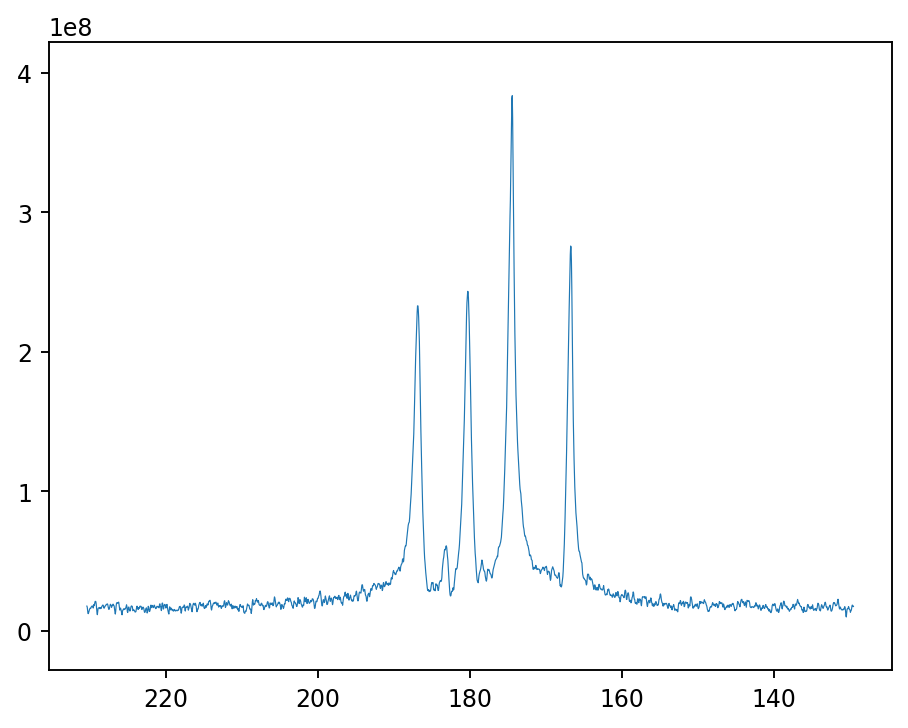

In [466]:
# First and last scan for Sum Up
# Select as a intial scan (ini) the first scan that has signal
# Select as the final scan (ene) the first scan that has no signal after all the peaks.
# The graph will show the integrated intensities for the selected scans

ini = 1 # First scan
ene = 18# Last scan



plt.figure(dpi=170)
    # plt.plot([184, 184],[min(futmag[i]), max(futmag[i])])
plt.plot(ppms, np.sum(futmag[ini-1:ene-1],0), linewidth = 0.5)
plt.gca().invert_xaxis()
plt.ylim(min(np.sum(futmag[ini-1:ene-1],0))-(max(np.sum(futmag[ini-1:ene-1],0))*0.1), max(np.sum(futmag[ini-1:ene-1],0))+(max(np.sum(futmag[ini-1:ene-1],0))*0.1))
plt.savefig(foldPath+'/'+foldNum+'/SumSpectra_NTP'+str(ini)+'_'+str(ene)+'.png')
plt.savefig(foldPath+'/'+foldNum+'/SumSpectra_NTP'+str(ini)+'_'+str(ene)+'.svg')

plt.show()

# Plot Stack of All Spectra Acquired

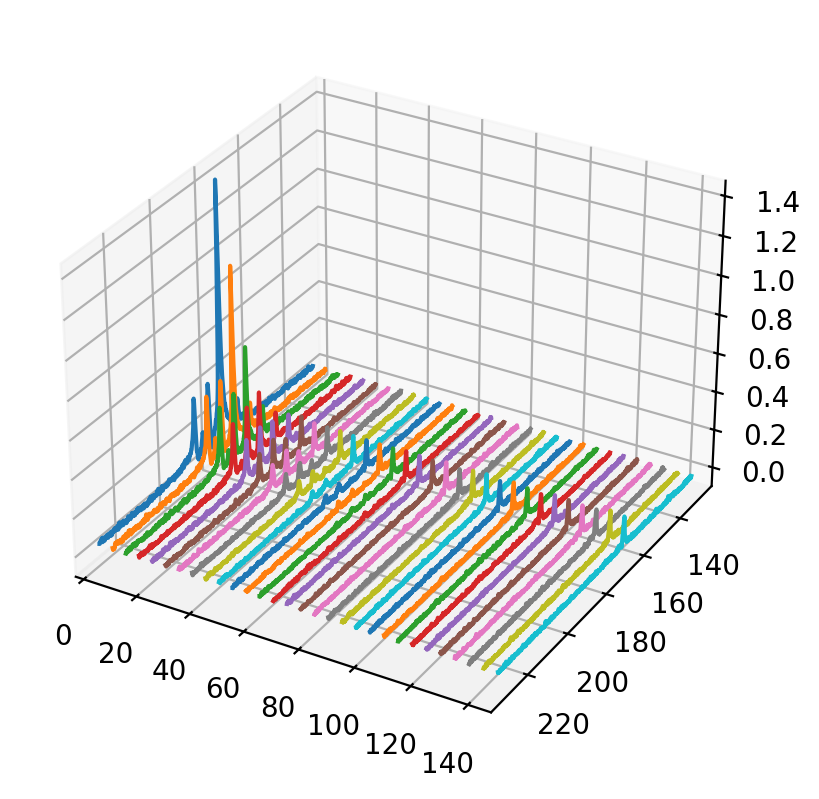

In [467]:
plot3D(5, NR, ppms, futmag, foldPath, foldNum) # First argument is time step

# Integrals

Pyruvate C1 (171.1 ppm)

Alanine C1 (176.5 ppm)

Pyruvate-hydrate C1 (179.5 ppm)

Lactate C1 (183.4 ppm)

## Selection of Integral Regions

Output()

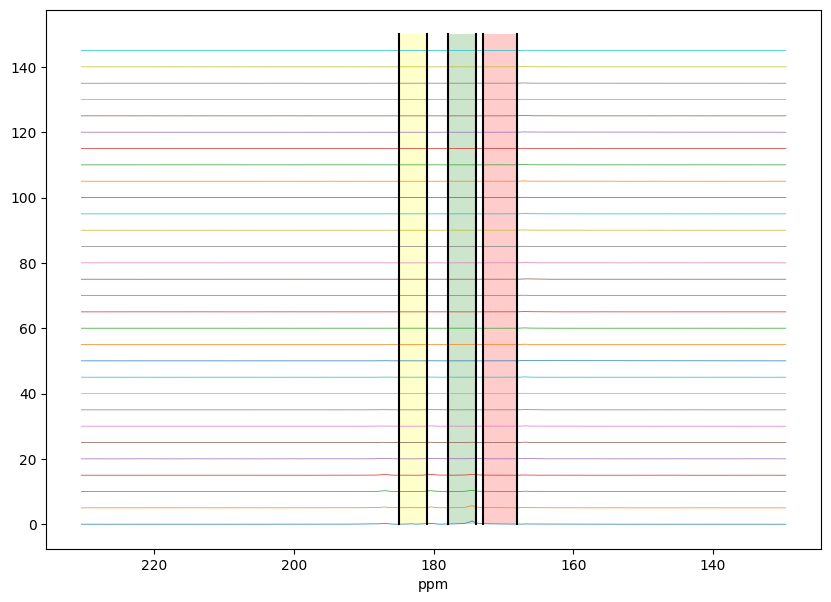

In [487]:
# With this interactive graph, select the PPM range on the X axis that corresponds to lactate, alanine and pyruvate
# first adjust multip to 100 to see the signal, the NTP to the ENE (first scan without signal), and then select the range for each metabolite with the sliders.
# These ranges for PPM will define the areas for the peaks in the next calculations for each time point. 
ts=5

mm=interactive(
        integRegs2,
        Piruvate = widgets.FloatRangeSlider(min=-185,max=-155,step=0.01,value=[-173, -168], readout = False, layout=Layout(width='1000px')),
        Alanine = widgets.FloatRangeSlider(min=-185,max=-165,step=0.01,value=[-178,-174], readout = False, layout=Layout(width='1000px')),
        Lactate = widgets.FloatRangeSlider(min=-195,max=-170,step=0.01,value=[-185, -181], readout = False, layout=Layout(width='1000px')), 
        zoomlow=widgets.IntRangeSlider(min=-len(ppms),max=0,step=1,value=[-len(ppms), 0], readout = False, description ='Zoom'),
        ppms=fixed(ppms), 
        futmag=fixed(futmag),
        foldPath=fixed(foldPath), 
        foldNum=fixed(foldNum),
        NR = fixed(NR), 
        multip=widgets.FloatSlider(min=1,max=100,step=1,value=1), 
        ntp=widgets.IntSlider(min=1,max=len(futmag),step=1,value=len(futmag)),
        ts=fixed(ts))


display(HBox(mm.children[-4:-1]))
display(HBox(mm.children[0:1]))
display(HBox(mm.children[1:2]))
display(HBox(mm.children[2:3]))
# display(HBox(mm.children[2:-4]))#Show all controls
display(mm.children[-1])

integRegs2([-185, -181], [-178, -174], [-173, -168], ppms, futmag, foldPath, foldNum, NR, ts, 1,[],[])



##  Plot the integral of the scans 
### From this point onwards the script may run without user intervention.

np.float64(1860621808.7486496)

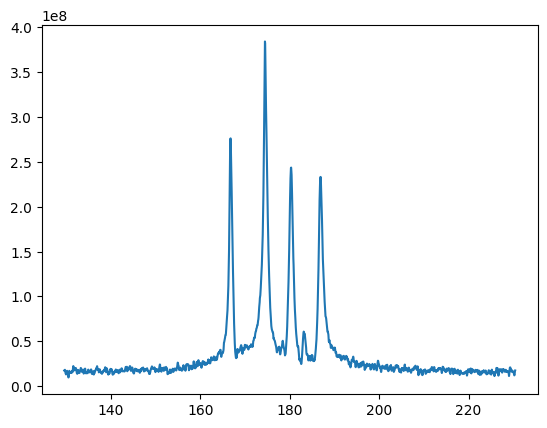

In [547]:
plt.plot(ppms, np.sum(futmag[ini-1:ene-1], 0))

sumdat = np.sum(futmag[ini-1:ene-1],0)

inters = np.zeros(1)
intSe = sumdat[(ppms > 165) & (ppms < 187)]
inters = auc(ppms[(ppms > 165) & (ppms < 187)], intSe)

inters

## Sum Up Integrals
### The integral areas will be calculated based on this graph

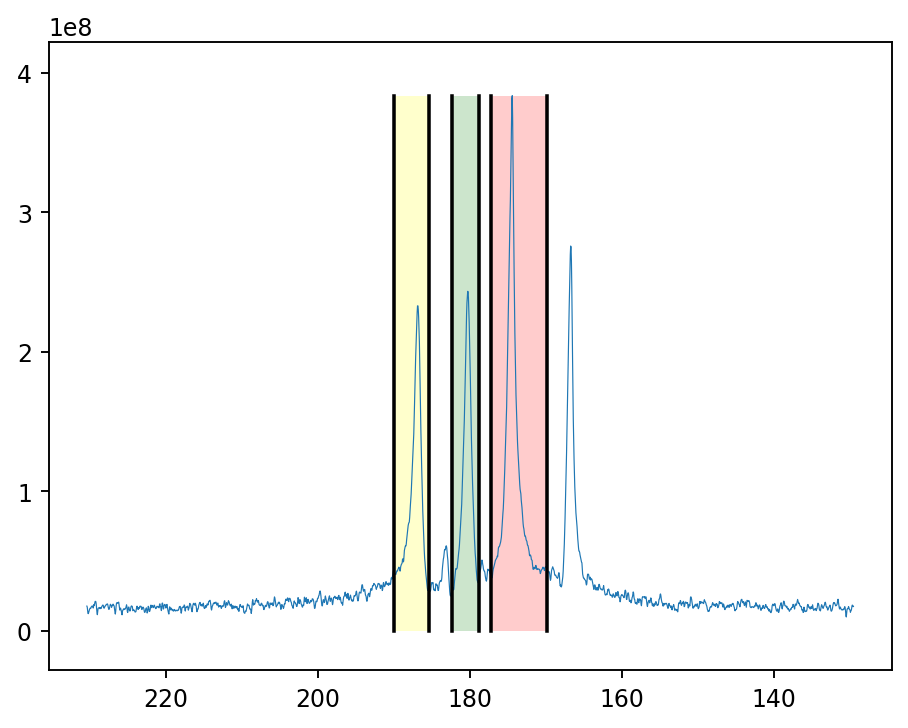

Pyruvate Integral: 741255510.9847959
Alanine  Integral: 360643508.41632676
Lactate  Integral: 417880672.65393496


In [548]:
PyrSU, AlaSU, LacSU = integralSumUp(ini, ene, ppms, futmag, foldPath, foldNum)

## Plot Integrals Over Time
In the last argument, 123 refers to Pyruvate, Alanine and Lactate. You can change the numbers to show only some of them instead of the three

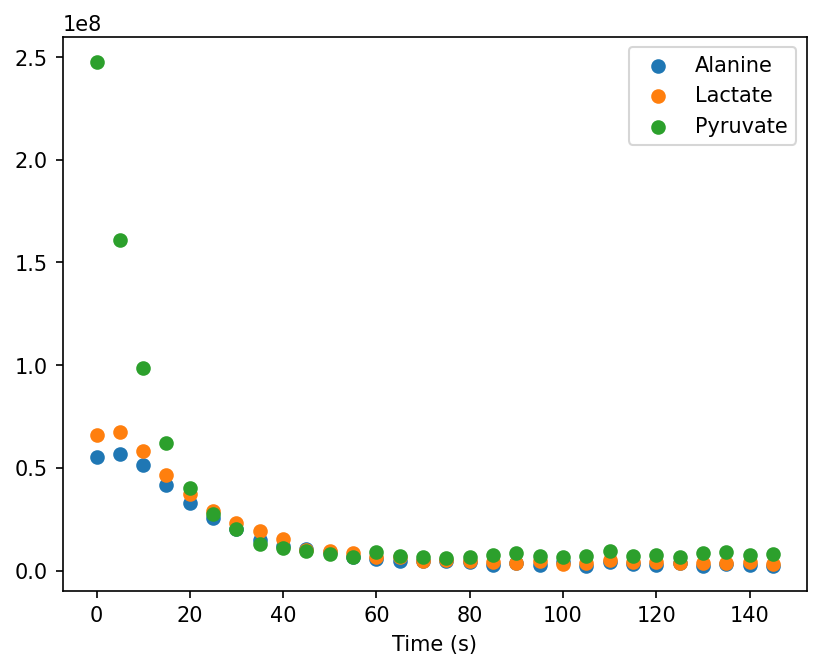

In [549]:
Pyr, Ala, Lac = plotInters(ppms,NR,futmag,foldPath,foldNum,123)

In [550]:
PyrMax = Pyr[np.max(Pyr) == Pyr][0]
ttpPyr = (np.where(Pyr == PyrMax)[0][0]+1)*5 # 5 is time delay between scans

LacMax = Lac[np.max(Lac) == Lac][0]
ttpLac = (np.where(Lac == LacMax)[0][0]+1)*5 # 5 is time delay between scans

AlaMax = Ala[np.max(Ala) == Ala][0]
ttpAla = (np.where(Ala == AlaMax)[0][0]+1)*5 # 5 is time delay between scans


print("Time to peak Pyruvate: "+str(ttpPyr)+" s")
print("Time to peak Lactate: "+str(ttpLac)+" s")
print("Time to peak Alanine: "+str(ttpAla)+" s")

Time to peak Pyruvate: 5 s
Time to peak Lactate: 10 s
Time to peak Alanine: 10 s


In [551]:
pwd

'c:\\Users\\Vicent\\OneDrive - IBEC\\MRIPyMy-main'

In [552]:
Pyr, Ala, Lac

(array([2.47615073e+08, 1.60938390e+08, 9.87603388e+07, 6.21986126e+07,
        4.03617984e+07, 2.74012672e+07, 2.00573435e+07, 1.31063404e+07,
        1.09682377e+07, 9.56771864e+06, 8.12326857e+06, 6.63011689e+06,
        8.90615832e+06, 7.17802917e+06, 6.64034315e+06, 6.14856749e+06,
        6.65390782e+06, 7.77692133e+06, 8.57024832e+06, 7.08165628e+06,
        6.79693877e+06, 7.22980305e+06, 9.64269681e+06, 7.11206451e+06,
        7.61355193e+06, 6.48756587e+06, 8.72608613e+06, 8.80120010e+06,
        7.56691362e+06, 8.14465128e+06]),
 array([55469156.28626855, 56859200.45047479, 51332983.206192  ,
        41837266.76629426, 32997086.5862814 , 25638703.62303226,
        20244194.38317064, 14833059.96370363, 11851857.11354351,
        10498692.16385325,  8893713.38191438,  6523648.23061528,
         5846038.99417306,  4446231.91991467,  4772778.50058025,
         4489695.30656208,  4109201.53975267,  2886171.87917413,
         3865615.30078964,  2750248.76112921,  4063003.73163159,

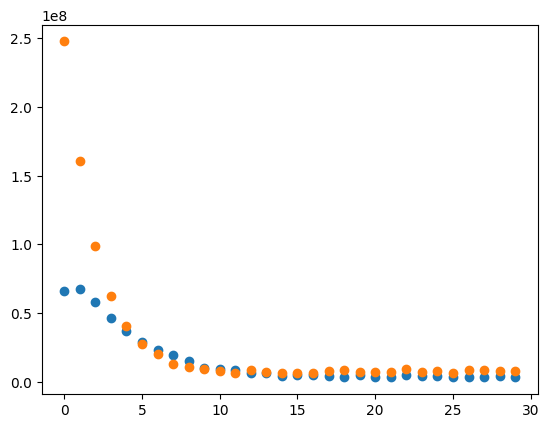

In [553]:
plt.scatter(range(len(Lac)),Lac)
plt.scatter(range(len(Pyr)),Pyr)

In [554]:
Lac

array([65935605.89571791, 67516435.43224041, 58230345.76164107,
       46445368.41178934, 37069192.32253959, 28934380.3535623 ,
       23290214.74234632, 19350218.73898984, 15388488.5572952 ,
       10201205.78915642,  9422934.41335154,  8637588.96533819,
        6507809.50202986,  6520882.09996898,  4599085.88810623,
        4973304.20578017,  4857611.57408164,  4020705.68641422,
        3852368.19430779,  4686339.73757417,  3174337.60834307,
        3589315.91121467,  5138103.13729141,  4247585.71153675,
        3934290.36587703,  3624438.91769243,  3462510.13944494,
        3706877.38170176,  4023148.76243849,  3243729.94386267])

In [555]:
'Ratio Pyruvate over Alanine: '+str(np.sum(Pyr[ini-1:ene-1])/np.sum(Ala[ini-1:ene-1]))

'Ratio Pyruvate over Alanine: 2.055369065811912'

In [556]:
'Ratio Pyruvate over Lactate: '+str(np.sum(Pyr[ini-1:ene-1])/np.sum(Lac[ini-1:ene-1]))

'Ratio Pyruvate over Lactate: 1.7738449262970857'

In [557]:
'Ratio Pyruvate over Total Signal: '+str(np.sum(Pyr[ini-1:ene-1])/inters)

'Ratio Pyruvate over Total Signal: 0.39839128376299265'

In [558]:
'Ratio Alanine over Total Signal: '+str(np.sum(Ala[ini-1:ene-1])/inters)

'Ratio Alanine over Total Signal: 0.19382956102125634'

In [559]:
'Ratio Lactate over Total Signal: '+str(np.sum(Lac[ini-1:ene-1])/inters)

'Ratio Lactate over Total Signal: 0.2245919459231633'

# Plot Lactate Over Pyruvate

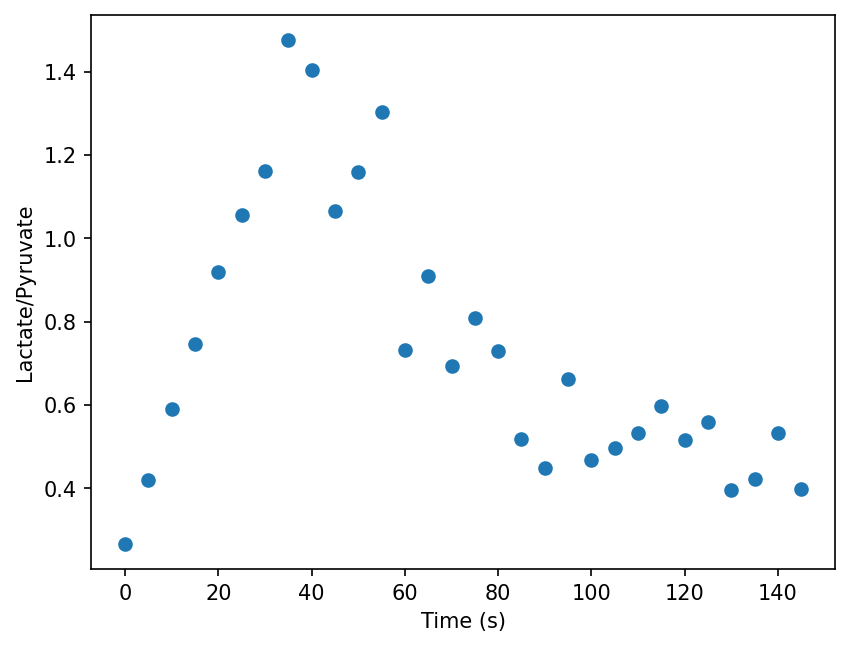

In [560]:
LacOverPyr(ppms, futmag, NR, foldPath, foldNum)

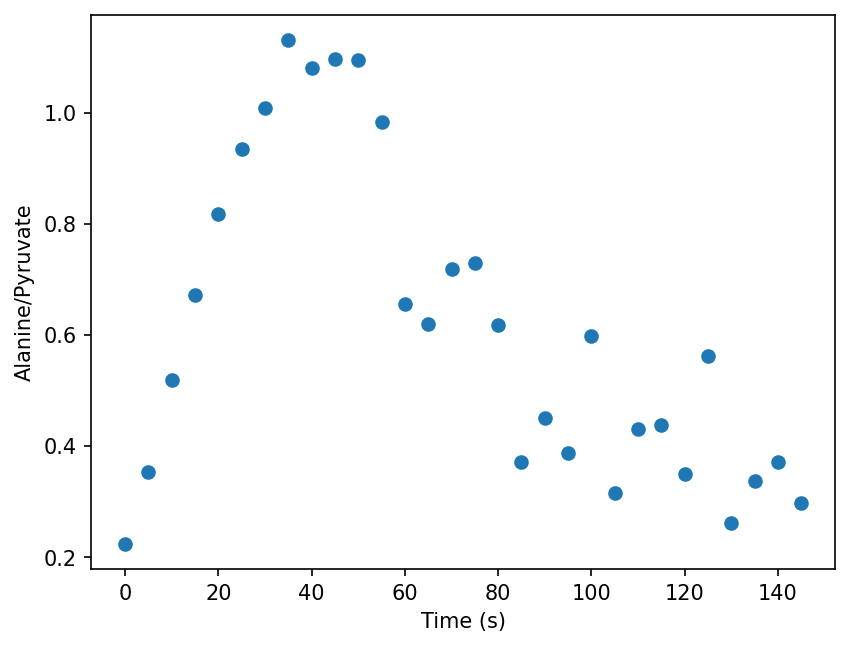

In [561]:
AlaOverPyr(ppms, futmag, NR, foldPath, foldNum)

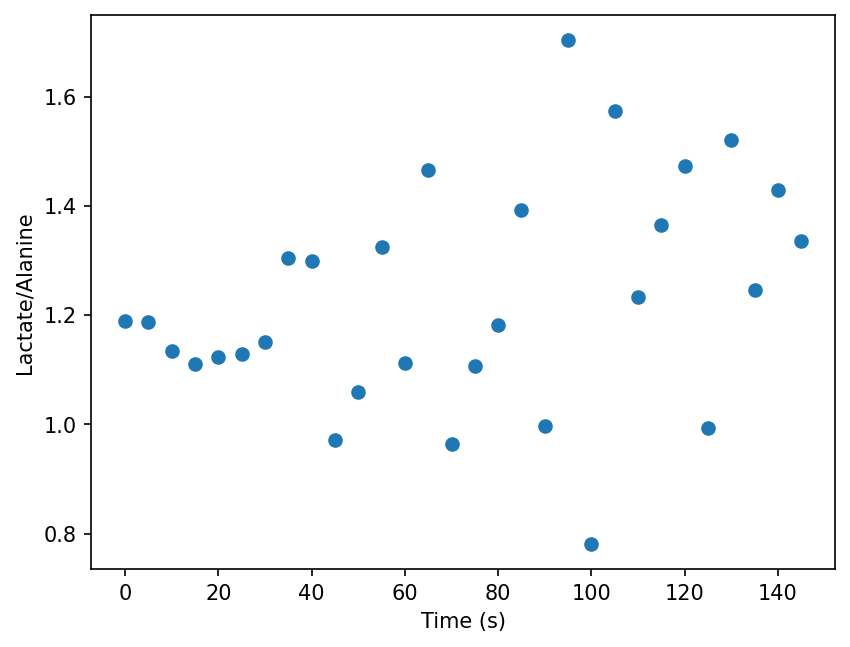

In [562]:
LacOverAla(ppms, futmag, NR, foldPath, foldNum)

# Extract Metadata

In [563]:
extrMetDat(foldPath)

STUDY NAME: liver slab 1-13C pyruvate


DATE BIRTH: 28 Jan 2023


REMARKS
<Project: Prova pilot\

Diet: HFD>



WEIGHT: 0.06




# -------------------------------------- THE END --------------------------------------

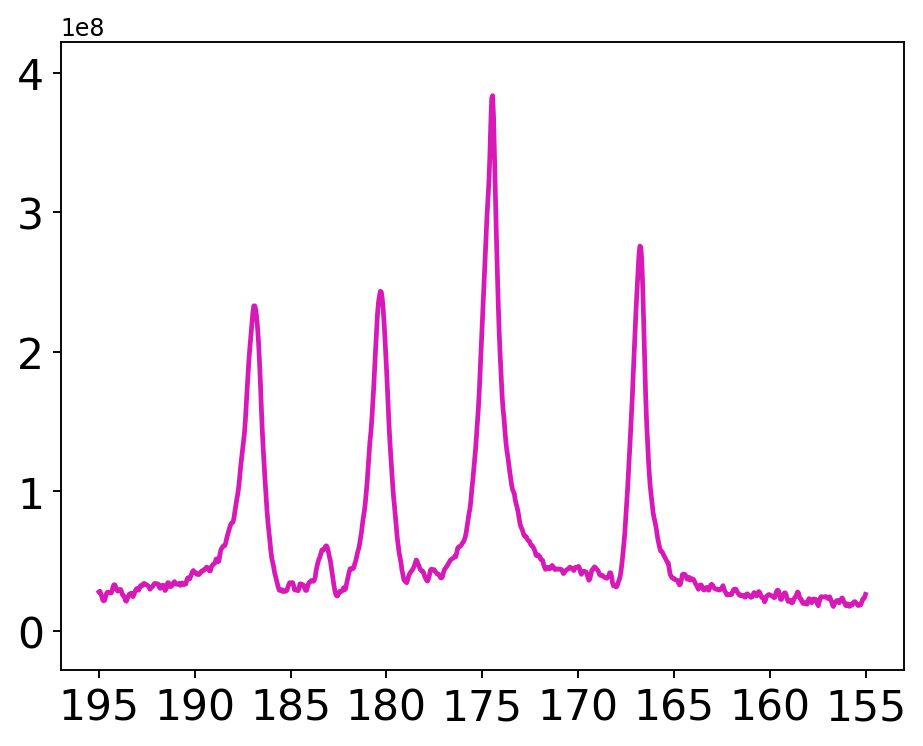

In [564]:

# i=5# Number of time points to consider for the sum


avb = np.logical_and(ppms<195,  ppms>155)

plt.figure(dpi=170)
    # plt.plot([184, 184],[min(futmag[i]), max(futmag[i])])
plt.plot(ppms[avb], np.sum(futmag[ini-1:ene-1],0)[avb], linewidth = 2, color="#D719B7")
plt.gca().invert_xaxis()
plt.ylim(min(np.sum(futmag[ini-1:ene-1],0))-(max(np.sum(futmag[ini-1:ene-1],0))*0.1), max(np.sum(futmag[ini-1:ene-1],0))+(max(np.sum(futmag[ini-1:ene-1],0))*0.1))

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)


plt.savefig(foldPath+'/'+foldNum+'/SumSpectra_ZOOM_NTP'+str(ini)+'_'+str(ene)+'.png')
plt.savefig(foldPath+'/'+foldNum+'/SumSpectra_ZOOM_NTP'+str(ini)+'_'+str(ene)+'.svg')


plt.show()